# Pricing the solver's settle-or-revert option

A winning solver can settle an order at whatever its routing is worth by the settlement deadline, or revert and pay a penalty. The right to revert is a put option: the capped payoff decomposes as `max(Y, -C) = Y + max(-C - Y, 0)`, the always-settle payoff plus a put on the surplus `Y` struck at `-C`. With no penalty the put is free, and free options distort bids. This notebook prices the put from the asset's short-term volatility and derives the penalty cap that follows.

**Payoffs.** Bid `s`, reference score `s_ref` (the counterfactual score without the winner), surplus over the reference `Y = R - s_ref` at settlement. Three outcomes:

| outcome | payoff |
|---|---|
| settle | `Y` |
| voluntary revert (price moved against the bid) | `-C` |
| forced revert (technical failure or limit price breached) | `-min(C, s_ref)` |

The full payoff is `max(Y, -C, -s_ref)`: the penalty can never exceed the score, so the cap only binds where `C < s_ref`. Analysis is at the tie (`s = s_ref`) unless bids are solved for explicitly.

**Route.** Section 1: data and the TSRV volatility input. Section 2: a minimal three-state example. Section 3: the put priced over a settlement window in closed form. Section 4: optimal bidding, and the revert rate at the bid solvers would actually place. Section 5: forced technical reverts folded into the model. Section 6: window-length scaling. Section 7: empirical replay on tick data. Section 8: out-of-sample validation of the volatility input. Section 9: the cap formula.

**Scope.** Reference score exogenous; driftless prices, so `C` is a break-even penalty, not a hedging premium; volatility inputs carry their 10-30% estimation band and pass through linearly.

In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import norm
from scipy.optimize import brentq

T_EXCL = 30                    # headline settlement window (s): ~3 blocks of exclusivity
T_FAST = 2                     # fast-path window (s); formula-only, see Section 9
T_GRID = [10, 30, 60]
Q_TARGET = 0.10                # revert-rate target; 5-15% is the working band
P_FORCED = 0.05                # technical (non-price) revert rate reported by solvers
LONG_KEY = "LONGTAIL (synthetic, 5x DOGE)"

# ---- plotting: static plotly ----
pio.renderers.default = "png"
pio.renderers["png"].scale = 2
C_PAIR = {"ETHUSDC": "#2a78d6", "DOGEUSDT": "#eb6834", LONG_KEY: "#4a3aa7"}
GRAY, INK, GRID, SURF, AXIS = "#898781", "#0b0b0b", "#e1e0d9", "#fcfcfb", "#c3c2b7"

def style(fig, w=1050, h=430, title=None):
    fig.update_layout(width=w, height=h, template="none", paper_bgcolor=SURF, plot_bgcolor=SURF,
                      font=dict(size=13, color=INK), margin=dict(l=65, r=30, t=60, b=50),
                      legend=dict(bgcolor="rgba(0,0,0,0)"))
    if title: fig.update_layout(title=dict(text=title, font=dict(size=15)))
    fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    return fig
print("params set")

params set


## 1. Data and the volatility input

Binance trades for ETHUSDC and DOGEUSDT, split into an estimation sample (May 1-20 2026) and five held-out days for validation (May 21-25). Preparation follows `short_term_volatility_estimation.ipynb`: duplicates dropped, bad prints removed with a rolling-median filter (3 MADs, floor max(2 ticks, 1 bp)). Missing daily files download on first run.

The May 1-20 estimate runs higher than the volatility notebook's May 1-3 figures because early May was quiet; the input refreshes with the data window. Volatility comes from TSRV (two-scale realized variance) on 5-minute windows: summing squared tick returns overstates variance because prices bounce between bid and ask; TSRV measures on the full tick grid (noise-dominated) and on sparse subgrids (mostly signal) and subtracts the scaled full-grid measure to cancel the noise. The per-second volatility below is the median TSRV window in per-second units, bps of order size. Estimating directly on 10-30s of ticks is not viable (too few trades, noise-dominated); estimating at 5 minutes and scaling by sqrt(time) is, and Section 8 validates that scaling out of sample.

A synthetic long-tail pair at 5x the DOGE volatility stands in for wide-spread assets until real data is added.

In [2]:
import os, zipfile, urllib.request, pandas as pd

CACHE = "data/binance_ticks"   # May 1-3 ships with the repo; other days download on first run
os.makedirs(CACHE, exist_ok=True)
DAYS_IS = [f"2026-05-{d:02d}" for d in range(1, 21)]     # in-sample: May 1-20
DAYS_OOS = [f"2026-05-{d:02d}" for d in range(21, 26)]   # out-of-sample: May 21-25
PAIRS_EMP = ["ETHUSDC", "DOGEUSDT"]
WINDOW_VOL_S = 300

def fetch(symbol, day):
    fn = f"{symbol}-aggTrades-{day}.zip"
    path = os.path.join(CACHE, fn)
    if not os.path.exists(path):
        urllib.request.urlretrieve(
            f"https://data.binance.vision/data/spot/daily/aggTrades/{symbol}/{fn}", path)
    return path

def load_ticks(symbol, days):
    frames = []
    for d in days:
        with zipfile.ZipFile(fetch(symbol, d)) as z:
            name = z.namelist()[0]
            hh = not z.open(name).read(64)[:1].isdigit()
            cols = ["aggId","price","qty","firstId","lastId","ts","isBuyerMaker","isBestMatch"]
            df = pd.read_csv(z.open(name), header=0 if hh else None, names=None if hh else cols)
            if hh:
                df.columns = [str(c).lower() for c in df.columns]
                tcol = [c for c in df.columns if "time" in c or c == "ts" or "transact" in c][0]
                df = df.rename(columns={tcol: "ts"})
            df = df[["price", "ts"]].astype({"ts": "int64", "price": float})
            unit = "us" if df["ts"].iloc[0] > 10**14 else "ms"
            df["t"] = pd.to_datetime(df["ts"], unit=unit, utc=True)
            frames.append(df[["t", "price"]])
    return pd.concat(frames).sort_values("t").reset_index(drop=True)

def clean(df, k=25, mad_mult=3.0, floor_ticks=2.0, floor_bps=1.0):
    df = df[(df.price > 0) & df.price.notna()].drop_duplicates(subset=["t", "price"]).copy()
    tick = np.median(np.diff(np.unique(np.sort(df.price.values))))
    med = df.price.rolling(2*k + 1, center=True, min_periods=k).median()
    mad = (df.price - med).abs().rolling(2*k + 1, center=True, min_periods=k).median()
    floor_abs = max(floor_ticks*tick, df.price.median()*floor_bps*1e-4)
    keep = ((df.price - med).abs() <= mad_mult*mad + floor_abs).fillna(True)
    return df[keep].set_index("t")

def rv_all(lp):
    r = np.diff(lp); return float(r @ r)

def tsrv(lp, K):
    # two-scale realized variance, finite-sample adjusted
    n = len(lp) - 1
    if n < 2*K + 2: return np.nan
    rva = np.mean([np.sum(np.diff(lp[k::K])**2) for k in range(K)])
    nbar = (n - K + 1)/K
    return max((rva - (nbar/n)*rv_all(lp))/(1 - nbar/n), 0.0)

TICKS = {p: clean(load_ticks(p, DAYS_IS)) for p in PAIRS_EMP}
TICKS_OOS = {p: clean(load_ticks(p, DAYS_OOS)) for p in PAIRS_EMP}
PX = {p: TICKS[p].price.resample("1s").last().ffill() for p in PAIRS_EMP}
PX_OOS = {p: TICKS_OOS[p].price.resample("1s").last().ffill() for p in PAIRS_EMP}

def block_sigmas(ticks, px):
    # per-5-min-block TSRV per-second vol (bps/sqrt(s)), aligned to the 1s price grid
    n_blocks = int((len(px) - 1)//WINDOW_VOL_S)
    edges = px.index[0] + pd.to_timedelta(np.arange(n_blocks + 1)*WINDOW_VOL_S, unit="s")
    pos = ticks.index.searchsorted(edges)
    lp_all = np.log(ticks.price.values)
    out = np.full(n_blocks, np.nan)
    for b in range(n_blocks):
        lp = lp_all[pos[b]:pos[b + 1]]
        if len(lp) < 200: continue
        Kw = max(2, min(int(round(len(lp)*10.0/WINDOW_VOL_S)), (len(lp) - 2)//2))
        out[b] = np.sqrt(tsrv(lp, Kw)/WINDOW_VOL_S)*1e4
    return out

SIG_BLOCKS = {p: block_sigmas(TICKS[p], PX[p]) for p in PAIRS_EMP}
SIG_BLOCKS_OOS = {p: block_sigmas(TICKS_OOS[p], PX_OOS[p]) for p in PAIRS_EMP}
SIGMA_1S = {p: float(np.nanmedian(SIG_BLOCKS[p])) for p in PAIRS_EMP}
SIGMA_1S[LONG_KEY] = 5*SIGMA_1S["DOGEUSDT"]
sigma_T = lambda pair, T: SIGMA_1S[pair]*np.sqrt(T)

for p in SIGMA_1S:
    print(f"{p:30s} TSRV per-second vol {SIGMA_1S[p]:.3f} bps/sqrt(s) | "
          f"vol over {T_EXCL}s = {sigma_T(p, T_EXCL):.2f} bps")

ETHUSDC                        TSRV per-second vol 0.452 bps/sqrt(s) | vol over 30s = 2.48 bps
DOGEUSDT                       TSRV per-second vol 0.838 bps/sqrt(s) | vol over 30s = 4.59 bps
LONGTAIL (synthetic, 5x DOGE)  TSRV per-second vol 4.191 bps/sqrt(s) | vol over 30s = 22.96 bps


## 2. A minimal example

Routing value `R` in {99, 100, 101} with equal probability, mean `mu` = 100. Settling earns `R - s_ref`; reverting costs `C`. Three properties drive everything:
- Revert rule: settle iff `R - s_ref >= -C`.
- Equilibrium bid: the bid only decides which auctions are won, so the profit-maximizing bid sets the tie profit `E[max(R - s, -C)]` to zero. This holds for every `C`, so expected profit alone cannot pin the penalty down.
- Put value at a truthful bid (OV = option value): `OV(C) = E[(mu - C - R)+]`, the expected saving from reverting.

The revert-rate panel below is computed at the optimal bid, not at `mu`: a solver who overbids reverts more often, since the threshold is the bid minus the penalty. The third panel overlays the bid premium and the put value on the same axes: they are structurally different objects. The put value is bounded and falls smoothly to zero at the never-revert level; the bid premium is what the mechanism actually feels, and it explodes as the penalty vanishes. The put value is the illustration; the bid and revert curves are the decision-relevant quantities.

In [3]:
R_STATES = np.array([99.0, 100.0, 101.0]); MU = 100.0

def tie_profit(s, C):
    return np.mean(np.maximum(R_STATES - s, -C))

def opt_bid(C):
    hi = R_STATES.max()
    if tie_profit(hi, C) >= 0: return hi        # bid the edge of the support
    return brentq(lambda s: tie_profit(s, C), MU - 0.01, hi)

def revert_rate(s, C):
    return np.mean(R_STATES - s < -C - 1e-9)   # tolerance for the indifference knife edge

Cs = np.linspace(0, 1.5, 301)
sstar = np.array([opt_bid(C) for C in Cs])
rr_opt = np.array([revert_rate(s, C) for s, C in zip(sstar, Cs)])
rr_mu = np.array([revert_rate(MU, C) for C in Cs])
ov = np.array([np.mean(np.maximum(MU - C - R_STATES, 0)) for C in Cs])

print("example check, s=100, s_ref=99.5: no-cap E =",
      round(np.mean(R_STATES - 99.5), 3), "| cap-0 E =", round(np.mean(np.maximum(R_STATES - 99.5, 0)), 3))
for C in [0.0, 0.2, 0.5, 1.0, 1.2]:
    s = opt_bid(C)
    print(f"C={C:.1f}: optimal bid {s:.2f} | revert rate at that bid {revert_rate(s, C):.0%} | "
          f"put value at truthful bid {np.mean(np.maximum(MU - C - R_STATES, 0)):.3f}")

example check, s=100, s_ref=99.5: no-cap E = 0.5 | cap-0 E = 0.667
C=0.0: optimal bid 101.00 | revert rate at that bid 67% | put value at truthful bid 0.333
C=0.2: optimal bid 100.60 | revert rate at that bid 67% | put value at truthful bid 0.267
C=0.5: optimal bid 100.25 | revert rate at that bid 33% | put value at truthful bid 0.167
C=1.0: optimal bid 100.00 | revert rate at that bid 0% | put value at truthful bid 0.000
C=1.2: optimal bid 100.00 | revert rate at that bid 0% | put value at truthful bid 0.000


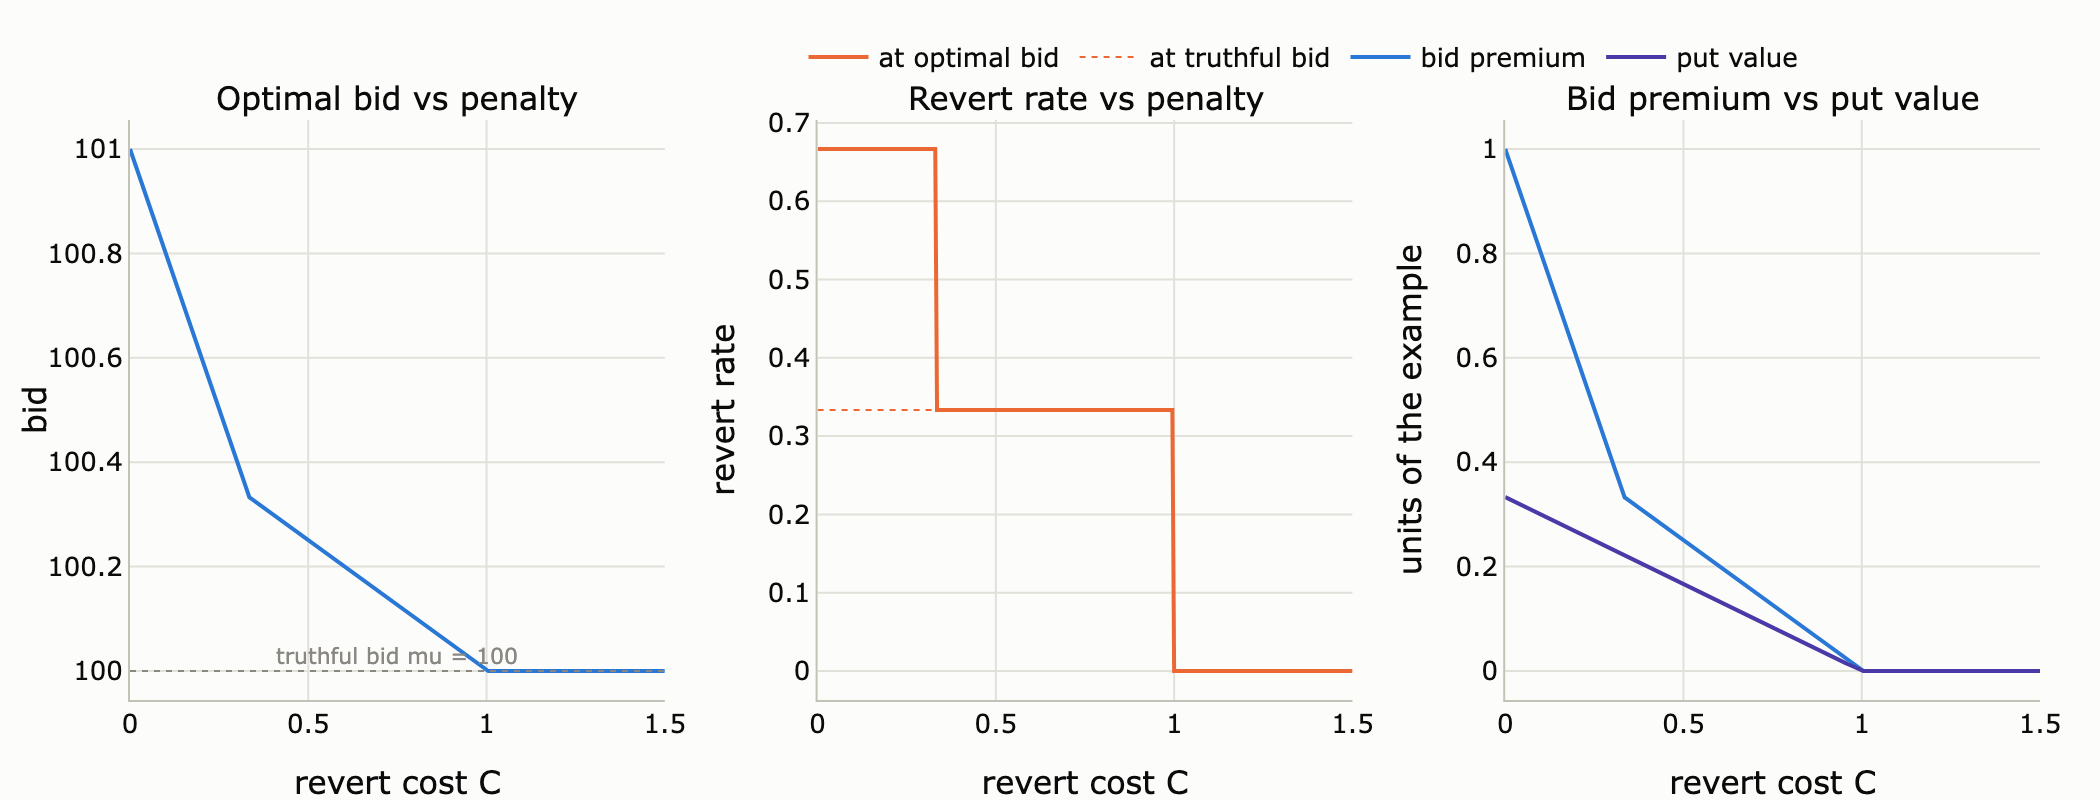

In [4]:
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.08,
                    subplot_titles=("Optimal bid vs penalty", "Revert rate vs penalty",
                                    "Bid premium vs put value"))
fig.add_trace(go.Scatter(x=Cs, y=sstar, mode="lines", line=dict(color="#2a78d6", width=2),
                         showlegend=False), row=1, col=1)
fig.add_hline(y=MU, line=dict(color=GRAY, dash="dot", width=1), row=1, col=1)
fig.add_annotation(text="truthful bid mu = 100", x=0.75, y=MU, yanchor="bottom", showarrow=False,
                   font=dict(color=GRAY, size=11), row=1, col=1)
fig.add_trace(go.Scatter(x=Cs, y=rr_opt, mode="lines", line=dict(color="#eb6834", width=2),
                         name="at optimal bid"), row=1, col=2)
fig.add_trace(go.Scatter(x=Cs, y=rr_mu, mode="lines", line=dict(color="#eb6834", width=1, dash="dot"),
                         name="at truthful bid"), row=1, col=2)
fig.add_trace(go.Scatter(x=Cs, y=sstar - MU, mode="lines", line=dict(color="#2a78d6", width=2),
                         name="bid premium"), row=1, col=3)
fig.add_trace(go.Scatter(x=Cs, y=ov, mode="lines", line=dict(color="#4a3aa7", width=2),
                         name="put value"), row=1, col=3)
for c in (1, 2, 3):
    fig.update_xaxes(title_text="revert cost C", row=1, col=c)
fig.update_yaxes(title_text="bid", row=1, col=1)
fig.update_yaxes(title_text="revert rate", row=1, col=2)
fig.update_yaxes(title_text="units of the example", row=1, col=3)
style(fig, h=400)
fig.update_layout(legend=dict(orientation="h", y=1.16, x=0.35))
fig.show()

## 3. The put over a settlement window

Let the surplus `Y` move drift-free with volatility `sigma_T = sigma_1s x sqrt(T)` over a window of `T` seconds (bps of order size). At the deadline the solver takes `max(Y, -C)`, i.e. holds a put struck at `-C`. With normal moves, at the tie:

put value `OV(C) = sigma_T x phi(d) - C x Phi(-d)`, revert probability `Phi(-C / sigma_T)`, with `d = C / sigma_T`.

(A binomial tree reproduces these to 4 decimals and its American version equals the European one: with no cost of waiting, settling early never pays. Checked below.)

Two facts set up the calibration:
- `OV(0) = sigma_T / sqrt(2 pi)`, about 0.4x window vol, is the free put per order. `OV(C)` never reaches zero at finite `C`, and removing 99% of it drives reverts to ~1%: pricing the put to zero is the no-cap corner. The anchor must be a tolerated revert rate instead.
- At a truthful bid, a revert-rate target `q` gives `C = sigma_T x z(1-q)`. But solvers do not bid truthfully at small caps; Section 4 recomputes the anchor at the bid they would actually place.

In [5]:
def ev_closed(sig_T, delta, C):
    d = (delta + C)/sig_T
    return -C + (delta + C)*norm.cdf(d) + sig_T*norm.pdf(d)

def ov_closed(sig_T, delta, C):
    d = (delta + C)/sig_T
    return sig_T*norm.pdf(d) - (delta + C)*norm.cdf(-d)

def p_revert(sig_T, delta, C):
    return norm.cdf(-(delta + C)/sig_T)

def p_call(a):
    # E[(Z - a)+] for standard normal Z; decreasing in a
    return norm.pdf(a) - a*norm.cdf(-a)

def beta_star(c, p_f=0.0):
    # equilibrium bid premium (vol units) at cap c (vol units), with forced-revert prob p_f:
    # solve (1 - p_f) * E[max(Z - beta, -c)] = p_f * c
    f = lambda b: (1 - p_f)*ev_closed(1.0, -b, c) - p_f*c
    return brentq(f, -8, 20)

def tree_value(sig_T, delta, C, N=400, american=False):
    dx = sig_T/np.sqrt(N)
    V = np.maximum(delta + (2*np.arange(N + 1) - N)*dx, -C)
    for n in range(N, 0, -1):
        V = 0.5*(V[1:] + V[:-1])
        if american:
            V = np.maximum(V, delta + (2*np.arange(n) - (n - 1))*dx)
    return float(V[0])

sT = sigma_T("DOGEUSDT", T_EXCL)
tv, av, cf = tree_value(sT, 0, 1), tree_value(sT, 0, 1, american=True), ev_closed(sT, 0, 1)
print(f"validation (DOGE, {T_EXCL}s, C=1): tree {tv:.4f} = closed form {cf:.4f} bps | "
      f"American - European = {av - tv:.1e}")
print(f"fixed-point check: beta at c=1 is {beta_star(1.0):.4f} vols "
      f"(revert threshold identity p_call({beta_star(1.0) - 1.0:+.4f}) = {p_call(beta_star(1.0) - 1.0):.4f})")

validation (DOGE, 30s, C=1): tree 1.3752 = closed form 1.3750 bps | American - European = 0.0e+00
fixed-point check: beta at c=1 is 0.1005 vols (revert threshold identity p_call(-0.8995) = 1.0000)


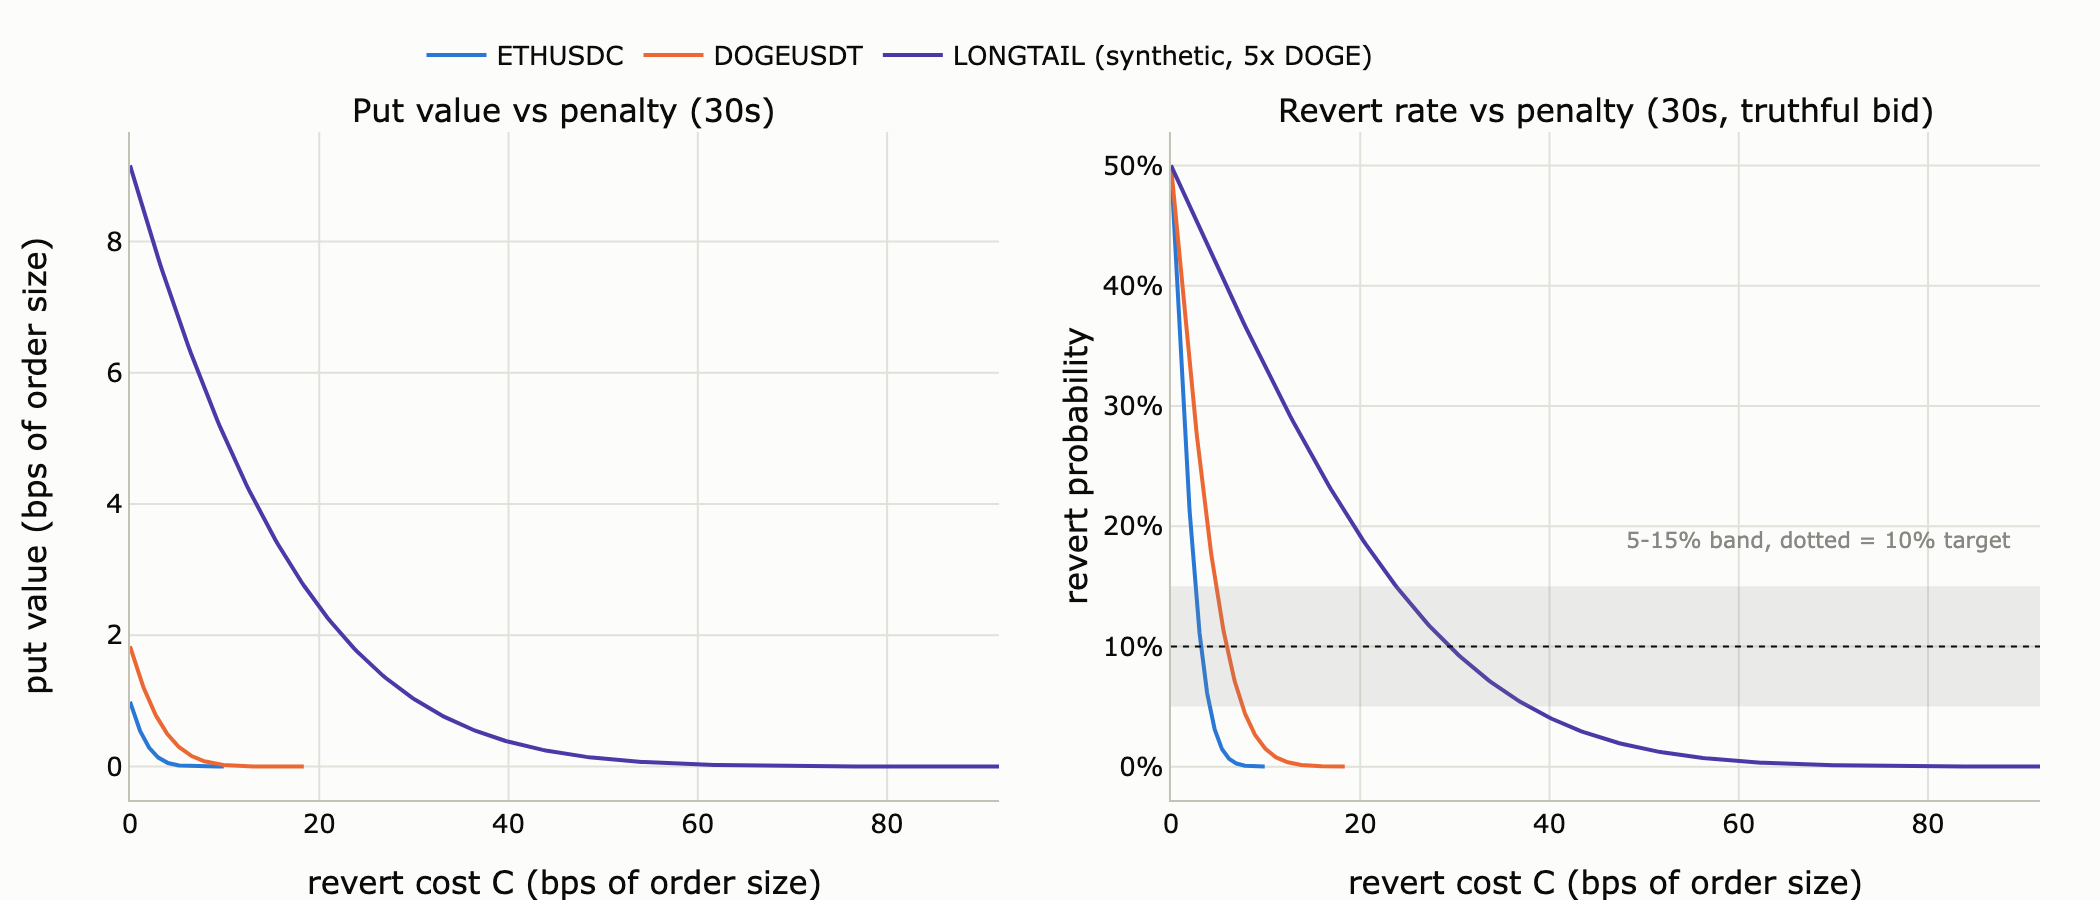

removing 99% of the put takes C = 2.27x window vol (same multiple for every pair), leaving reverts at 1.2%
truthful-bid anchor at the 10% target: C = 1.28x window vol


In [6]:
EPS_FRAC = 0.01
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=(f"Put value vs penalty ({T_EXCL}s)",
                                    f"Revert rate vs penalty ({T_EXCL}s, truthful bid)"))
for pair, col in C_PAIR.items():
    sT = sigma_T(pair, T_EXCL)
    Cg = np.linspace(0, 4*sT, 300)
    fig.add_trace(go.Scatter(x=Cg, y=[ov_closed(sT, 0, C) for C in Cg], mode="lines",
                             line=dict(color=col, width=2), name=pair), row=1, col=1)
    fig.add_trace(go.Scatter(x=Cg, y=[p_revert(sT, 0, C) for C in Cg], mode="lines",
                             line=dict(color=col, width=2), showlegend=False), row=1, col=2)
fig.add_hrect(y0=0.05, y1=0.15, fillcolor="rgba(137,135,129,0.15)", line_width=0, row=1, col=2)
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1), row=1, col=2)
fig.add_annotation(text="5-15% band, dotted = 10% target", x=0.97, xref="x2 domain", y=0.19,
                   xanchor="right", showarrow=False, font=dict(color=GRAY, size=11), row=1, col=2)
fig.update_xaxes(title_text="revert cost C (bps of order size)", row=1, col=1)
fig.update_xaxes(title_text="revert cost C (bps of order size)", row=1, col=2)
fig.update_yaxes(title_text="put value (bps of order size)", row=1, col=1)
fig.update_yaxes(title_text="revert probability", tickformat=".0%", row=1, col=2)
style(fig, h=450)
fig.update_layout(legend=dict(orientation="h", y=1.16, x=0.15))
fig.show()

sT = sigma_T("ETHUSDC", T_EXCL); ov0 = ov_closed(sT, 0, 0)
cstar = brentq(lambda C: ov_closed(sT, 0, C) - EPS_FRAC*ov0, 0, 8*sT)
print(f"removing 99% of the put takes C = {cstar/sT:.2f}x window vol "
      f"(same multiple for every pair), leaving reverts at {p_revert(sT, 0, cstar):.1%}")
print(f"truthful-bid anchor at the {Q_TARGET:.0%} target: C = {norm.ppf(1-Q_TARGET):.2f}x window vol")

## 4. Optimal bidding, and the revert rate that comes with it

The equilibrium bid premium `b*` (in vol units, `beta = b*/sigma_T`) solves the zero-tie-profit fixed point `E[max(Z - beta, -c)] = 0`, equivalently `beta = OV(c - beta)`: the premium equals the put value at the shifted strike. Consequences:
- The revert threshold moves with the bid: a solver who bid `mu + b*` reverts when the move falls below `b* - C`, so the revert rate is `Phi((b* - C)/sigma_T)`, strictly above the truthful-bid rate. At small caps the gap is large (rate tends to 1, not 1/2).
- Calibration must use this curve. Setting the revert rate at the optimal bid to `q` has a closed form: `C = sigma_T x [z(1-q) x Phi(z(1-q)) + phi(z(1-q))]`. At the 10% target that is k = 1.33 (vs 1.28 truthful); truthful bidding is the large-cap limit.
- The same-axes overlay shows the structural difference flagged in Section 2, now in the continuous case: the put value is bounded (0.4 vols at `C` = 0) while the bid premium diverges as the cap vanishes; the two converge only at large caps.

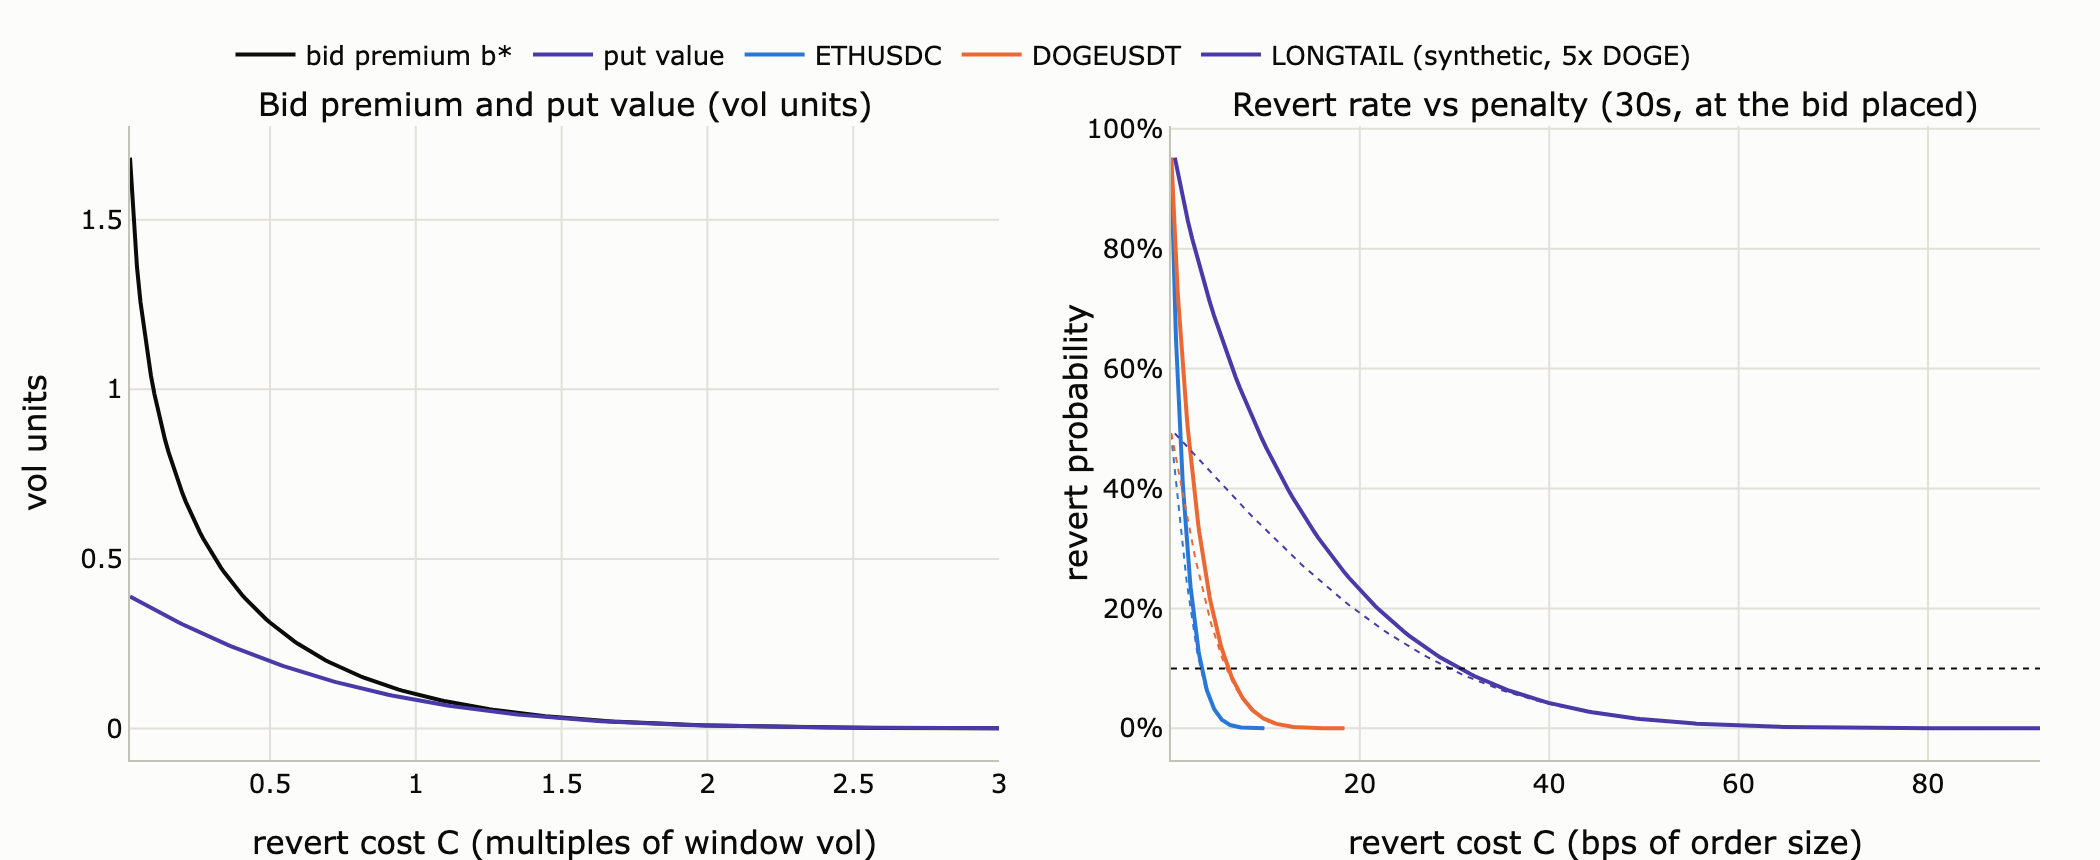

Right panel: solid = revert rate at the optimal bid, dotted = at a truthful bid.

cap multiple k = C/vol_T needed for a revert-rate target, truthful vs optimal bidding:
  q = 5%: truthful k = 1.645 | optimal-bid k = 1.666
  q = 10%: truthful k = 1.282 | optimal-bid k = 1.329
  q = 15%: truthful k = 1.036 | optimal-bid k = 1.114


In [7]:
cg = np.linspace(0.02, 3, 250)
betas = np.array([beta_star(c) for c in cg])
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=("Bid premium and put value (vol units)",
                                    f"Revert rate vs penalty ({T_EXCL}s, at the bid placed)"))
fig.add_trace(go.Scatter(x=cg, y=betas, mode="lines", line=dict(color=INK, width=2),
                         name="bid premium b*"), row=1, col=1)
fig.add_trace(go.Scatter(x=cg, y=[ov_closed(1.0, 0, c) for c in cg], mode="lines",
                         line=dict(color="#4a3aa7", width=2), name="put value"), row=1, col=1)
for pair, col in C_PAIR.items():
    sT = sigma_T(pair, T_EXCL)
    Cg = np.linspace(0.02*sT, 4*sT, 200)
    rr = [norm.cdf(beta_star(C/sT) - C/sT) for C in Cg]
    fig.add_trace(go.Scatter(x=Cg, y=rr, mode="lines", line=dict(color=col, width=2),
                             name=pair), row=1, col=2)
    fig.add_trace(go.Scatter(x=Cg, y=[p_revert(sT, 0, C) for C in Cg], mode="lines",
                             line=dict(color=col, width=1, dash="dot"), showlegend=False), row=1, col=2)
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1), row=1, col=2)
fig.update_xaxes(title_text="revert cost C (multiples of window vol)", row=1, col=1)
fig.update_xaxes(title_text="revert cost C (bps of order size)", row=1, col=2)
fig.update_yaxes(title_text="vol units", row=1, col=1)
fig.update_yaxes(title_text="revert probability", tickformat=".0%", row=1, col=2)
style(fig, h=430)
fig.update_layout(legend=dict(orientation="h", y=1.16, x=0.05))
fig.show()
print("Right panel: solid = revert rate at the optimal bid, dotted = at a truthful bid.")
print()
print("cap multiple k = C/vol_T needed for a revert-rate target, truthful vs optimal bidding:")
for q in (0.05, 0.10, 0.15):
    z = norm.ppf(1 - q)
    print(f"  q = {q:.0%}: truthful k = {z:.3f} | optimal-bid k = {z*norm.cdf(z) + norm.pdf(z):.3f}")

### Decomposing the bid premium

Why does the premium exceed the put value? Because a bid is a contingent promise: the extra amount is only delivered when the solver settles, and overbidding itself widens the set of states where it reverts. Splitting the equilibrium condition state by state gives an exact three-part identity, each part a priceable object:

> `b* = OV(c) + b* x Phi(-c) + PS(b*)`

- **Truthful-bid put**, `OV(c)`: the put the cap creates at a truthful bid. The part intuition prices.
- **Revert-state refund**, `b* x Phi(-c)`: the slice of the promised premium never paid, because in those states the solver was reverting anyway.
- **Default option on the overbid**, `PS(b*) = OV(c - b*) - OV(c) - b* x Phi(-c)`: the value of reverting in the extra band of states the overbid opens (moves between `c` and `c - b*` below fair value), where a truthful bidder settles but the overbidder defaults on its own promise. This is the genuinely strategic piece, and the correctly sized version of the "self-created optionality" intuition.

The three terms are nonnegative and sum exactly to the premium, so the stacked areas below reach the premium line. It is exact accounting of the equilibrium `b* = OV(c - b*)` split by strike shift, with PS evaluated at the equilibrium bid, as any equilibrium markup must be; equivalently, the earlier settle-contingent form is `b* = [OV(c) + PS(b*)] / Phi(c)`. In the running example (vol 10 bps, cap 10 bps): 1.0 bp = 0.83 put + 0.16 refund + 0.01 default option.

The cap connection: near the recommended cap (`c` around 1.3) the premium is ~85% genuine put compensation. At `c` = 0.05 it is ~70% refund plus default option, i.e. mostly empty promise: a floor on the cap is what keeps bids meaning something.

identity check: max |PS residual - PS closed form| = 4.5e-13 | min component value = 3.2e-10


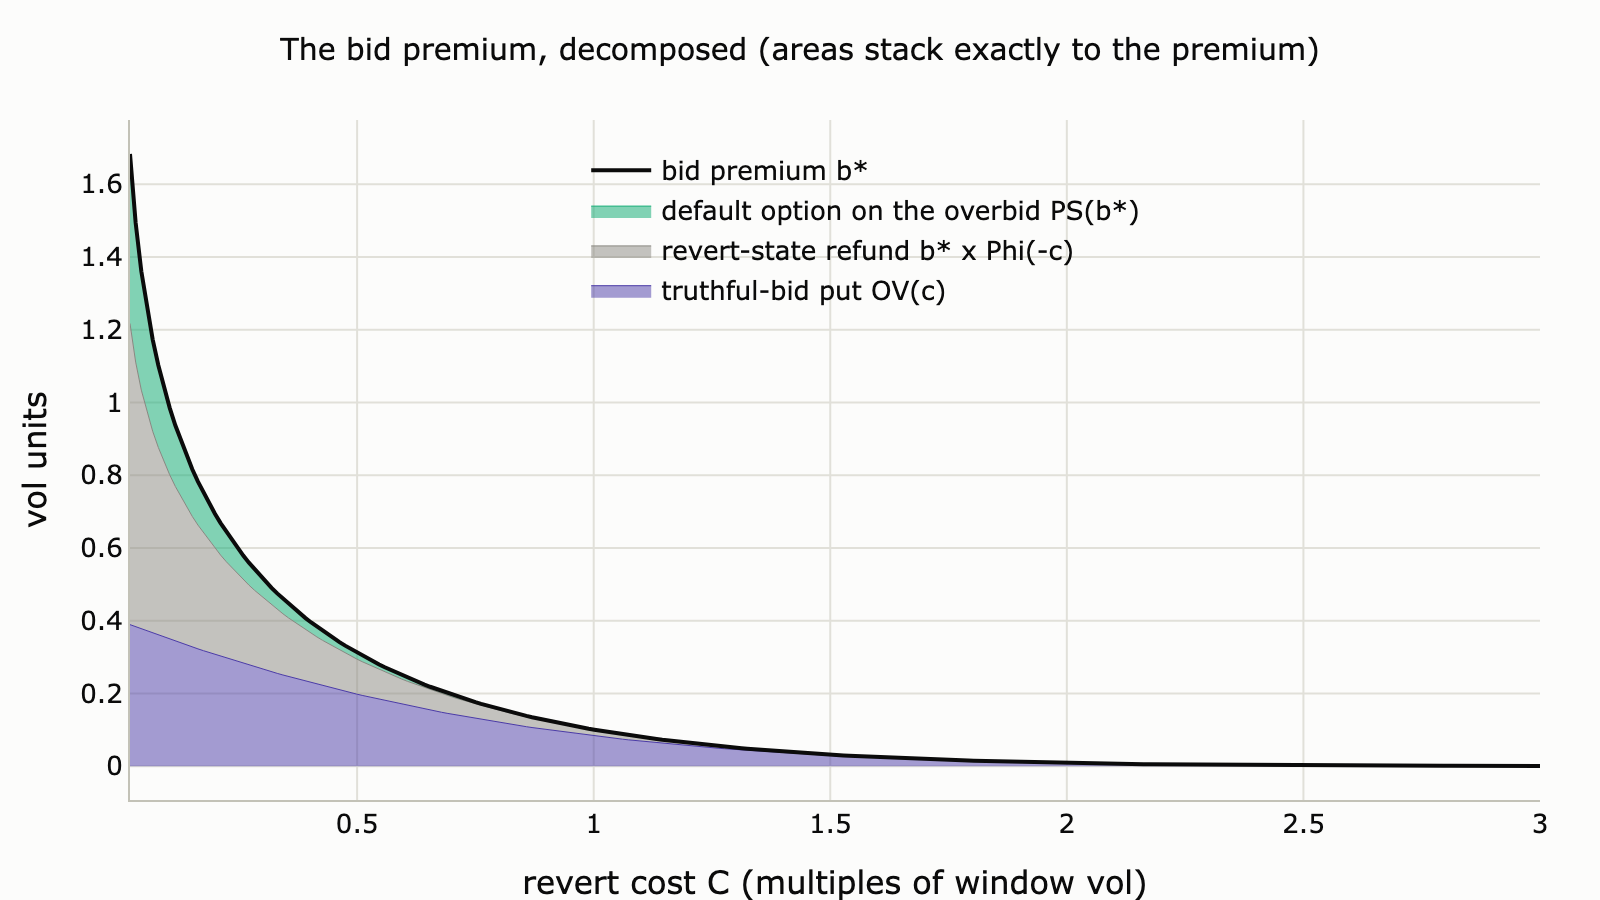

    c       b*     put  refund  default opt               shares
 2.00   0.0087  0.0085  0.0002       0.0000   97.7% /  2.3% /  0.0%
 1.00   0.1005  0.0833  0.0159       0.0013   82.9% / 15.9% /  1.3%
 0.50   0.3120  0.1978  0.0962       0.0179   63.4% / 30.9% /  5.7%
 0.20   0.6929  0.3069  0.2915       0.0945   44.3% / 42.1% / 13.6%
 0.05   1.3056  0.3744  0.6268       0.3044   28.7% / 48.0% / 23.3%


In [8]:
ovp = lambda x: ov_closed(1.0, 0.0, x)              # put value in vol units at strike shift x
comp_put = np.array([ovp(c) for c in cg])            # truthful-bid put
comp_refund = betas*norm.cdf(-cg)                    # revert-state refund
comp_ps = betas - comp_put - comp_refund             # default option on the overbid
ps_direct = np.array([ovp(c - b) - ovp(c) - b*norm.cdf(-c) for c, b in zip(cg, betas)])
print(f"identity check: max |PS residual - PS closed form| = {np.max(np.abs(comp_ps - ps_direct)):.1e}"
      f" | min component value = {min(comp_put.min(), comp_refund.min(), comp_ps.min()):.1e}")

fig = go.Figure()
for name, series, col in [("truthful-bid put OV(c)", comp_put, "rgba(74,58,167,0.5)"),
                          ("revert-state refund b* x Phi(-c)", comp_refund, "rgba(137,135,129,0.5)"),
                          ("default option on the overbid PS(b*)", comp_ps, "rgba(27,175,122,0.55)")]:
    fig.add_trace(go.Scatter(x=cg, y=series, mode="lines", stackgroup="one",
                             line=dict(width=0.5, color=col.replace("0.5", "1").replace("0.55", "1")),
                             fillcolor=col, name=name))
fig.add_trace(go.Scatter(x=cg, y=betas, mode="lines", line=dict(color=INK, width=2),
                         name="bid premium b*"))
fig.update_xaxes(title="revert cost C (multiples of window vol)")
fig.update_yaxes(title="vol units")
style(fig, w=800, h=450, title="The bid premium, decomposed (areas stack exactly to the premium)")
fig.update_layout(legend=dict(x=0.32, y=0.97))
fig.show()

print(f"{'c':>5} {'b*':>8} {'put':>7} {'refund':>7} {'default opt':>12} {'shares':>20}")
for c in [2.0, 1.0, 0.5, 0.2, 0.05]:
    b = beta_star(c)
    put, ref = ovp(c), b*norm.cdf(-c)
    ps = b - put - ref
    print(f"{c:5.2f} {b:8.4f} {put:7.4f} {ref:7.4f} {ps:12.4f}"
          f"   {put/b:5.1%} / {ref/b:5.1%} / {ps/b:5.1%}")

## 5. Forced technical reverts

Around 5% of settlements fail for non-price reasons (node issues, missed blocks). Modeled as a mixture: with probability `p_f` the draw is a forced revert (pay `C`, no choice); otherwise the model above. Two effects:
- Bids fall. The tie condition becomes `(1 - p_f) x E[max(Z - beta, -c)] = p_f x c`, so the expected forced penalty is priced into the bid; at large caps the premium tends to `-p_f x C / (1 - p_f)`, an underbid of roughly the expected forced penalty per settlement. This is the mechanism behind bidding below fair value under heavy caps.
- The anchor depends on which revert rate the target refers to. If the 10% target means price-driven reverts only, Section 4's k stands. If it means total observed reverts, the price-driven allowance shrinks to `(q - p_f)/(1 - p_f)` (5.3% at `q` = 10%, `p_f` = 5%) and k rises accordingly; the target is infeasible once `p_f >= q`. This convention choice moves the cap more than anything else in the notebook, and it is a policy decision, not a modeling one.

Keeping the mechanism simple (one cap, no separate forgiveness process) means quoting the cap under the total-revert convention; both are computed below.

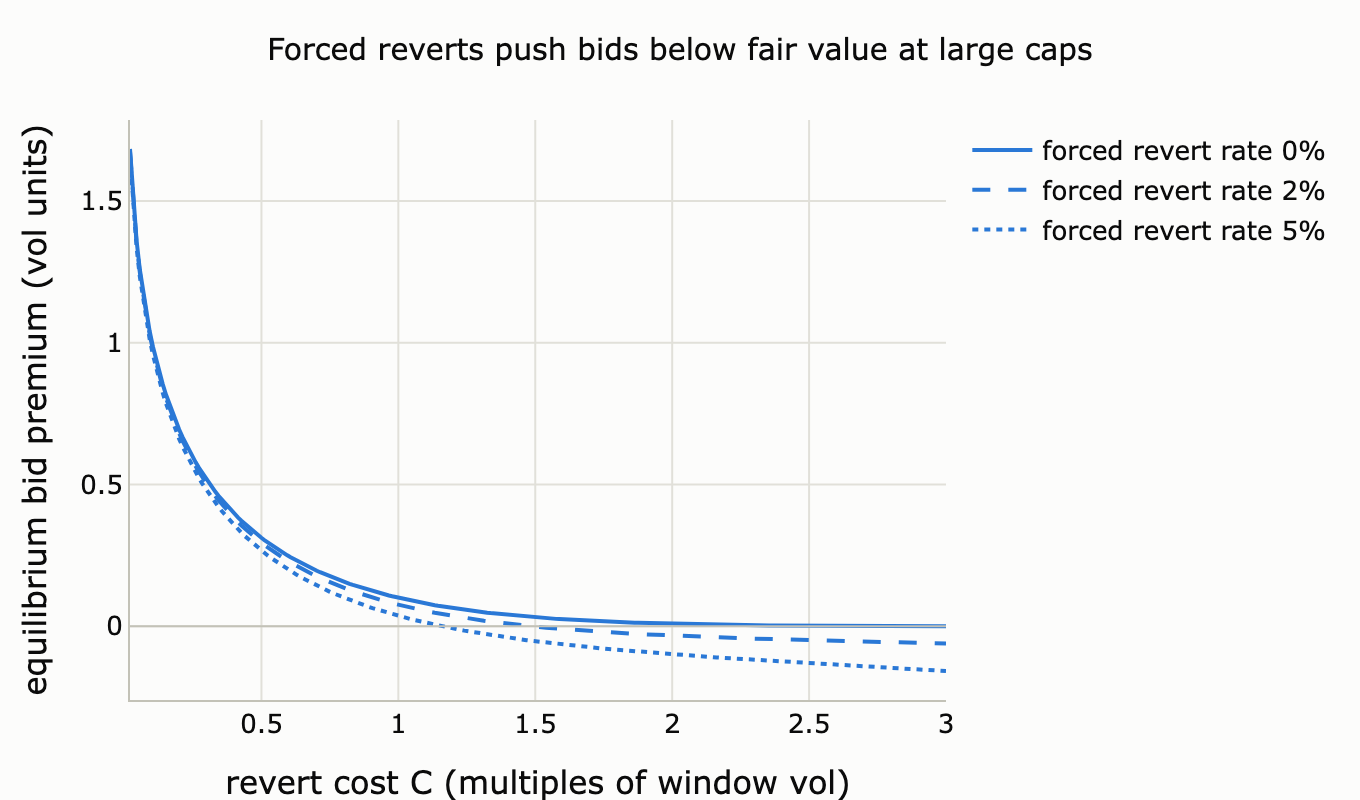

cap multiple k at the 10% target, with p_f = 5% forced reverts:
  target on price-driven reverts only: k = 1.262
  target on total observed reverts:    k = 1.560
  (no forced reverts, Section 4:       k = 1.329)


In [9]:
fig = go.Figure()
for p_f, dash in [(0.0, "solid"), (0.02, "dash"), (0.05, "dot")]:
    fig.add_trace(go.Scatter(x=cg, y=[beta_star(c, p_f) for c in cg], mode="lines",
                             line=dict(color="#2a78d6", width=2, dash=dash),
                             name=f"forced revert rate {p_f:.0%}"))
fig.add_hline(y=0, line=dict(color=AXIS, width=1))
fig.update_xaxes(title="revert cost C (multiples of window vol)")
fig.update_yaxes(title="equilibrium bid premium (vol units)")
style(fig, w=680, h=400, title="Forced reverts push bids below fair value at large caps")
fig.show()

def k_anchor(q, p_f, convention):
    # cap multiple c solving: revert rate at the equilibrium bid = target
    if convention == "price":
        target = q
    else:
        if p_f >= q: return np.nan
        target = (q - p_f)/(1 - p_f)
    f = lambda c: norm.cdf(beta_star(c, p_f) - c) - target
    return brentq(f, 0.05, 8)

K_CONV = {}
print(f"cap multiple k at the {Q_TARGET:.0%} target, with p_f = {P_FORCED:.0%} forced reverts:")
K_CONV["price"] = k_anchor(Q_TARGET, P_FORCED, "price")
K_CONV["total"] = k_anchor(Q_TARGET, P_FORCED, "total")
print(f"  target on price-driven reverts only: k = {K_CONV['price']:.3f}")
print(f"  target on total observed reverts:    k = {K_CONV['total']:.3f}")
print(f"  (no forced reverts, Section 4:       k = {k_anchor(Q_TARGET, 0.0, 'price'):.3f})")

## 6. The window length prices the put too

Everything scales with `sigma_T = sigma_1s x sqrt(T)`: doubling the window multiplies the free put and the required penalty by sqrt(2). The current exclusivity is about 3 blocks (~26-30s), which sets the headline `T` = 30s; a ~2s fast path scales the same numbers down by sqrt(15). A penalty-free window is not free: its length sets the size of the put handed to the winner.

In [10]:
print("free put OV(0) per order, bps of order size:")
Ts = [T_FAST] + T_GRID
print(f"{'pair':30s}" + "".join(f"  @ {T:3d}s" for T in Ts))
for pair in SIGMA_1S:
    print(f"{pair:30s}" + "".join(f"  {ov_closed(sigma_T(pair, T), 0, 0):5.2f}" for T in Ts))

free put OV(0) per order, bps of order size:
pair                            @   2s  @  10s  @  30s  @  60s
ETHUSDC                          0.26   0.57   0.99   1.40
DOGEUSDT                         0.47   1.06   1.83   2.59
LONGTAIL (synthetic, 5x DOGE)    2.36   5.29   9.16  12.95


## 7. Empirical replay on the tick data

The closed forms assume normal moves. This section replays the auction cycle on the data: bid fair value (the mid) at the /solve moment, `T` seconds to the settle deadline, payoff `max(move, -cap)` per order in bps. Sweeping the cap gives the average payoff of participating and the share of windows reverted.

- Dotted curves: the normal model at the TSRV vol. Solid: the data, which adds bid-ask bounce, fat tails and the coarse DOGE tick (~0.9 bps, the steps in its revert curve).
- The cap at the 10% revert target reads directly off the empirical distribution as its 10% quantile (no model needed); the multiple `k` = cap / TSRV window vol makes it transferable across assets and windows. Both are reported, under truthful and optimal bidding (the optimal-bid version lifts the threshold by the bid premium).
- The replay runs on the 20 estimation days; the per-day spread of `k` below is the sampling error bar. Extending to 3+ months and more pairs remains the next step.
- With driftless prices the average payoff is positive at every cap; its size is the subsidy deliberately left to the winner.

In [11]:
def windows_bps(px, T):
    v = px.values
    n = (len(v) - 1)//T
    p0 = v[: n*T: T].reshape(n, 1)
    paths = (v[: n*T].reshape(n, T)/p0 - 1.0)*1e4               # running move vs the bid moment
    end = (v[T: n*T + 1: T].reshape(n, 1)/p0 - 1.0)[:, 0]*1e4   # move at the settle deadline
    return paths, end

for p in PAIRS_EMP:
    _, end = windows_bps(PX[p], T_EXCL)
    print(f"{p}: {len(end):,} non-overlapping {T_EXCL}s windows | raw std {end.std():.2f} bps "
          f"vs TSRV vol {sigma_T(p, T_EXCL):.2f} bps (gap = bounce + tails)")

ETHUSDC: 57,599 non-overlapping 30s windows | raw std 3.89 bps vs TSRV vol 2.48 bps (gap = bounce + tails)
DOGEUSDT: 57,599 non-overlapping 30s windows | raw std 5.91 bps vs TSRV vol 4.59 bps (gap = bounce + tails)


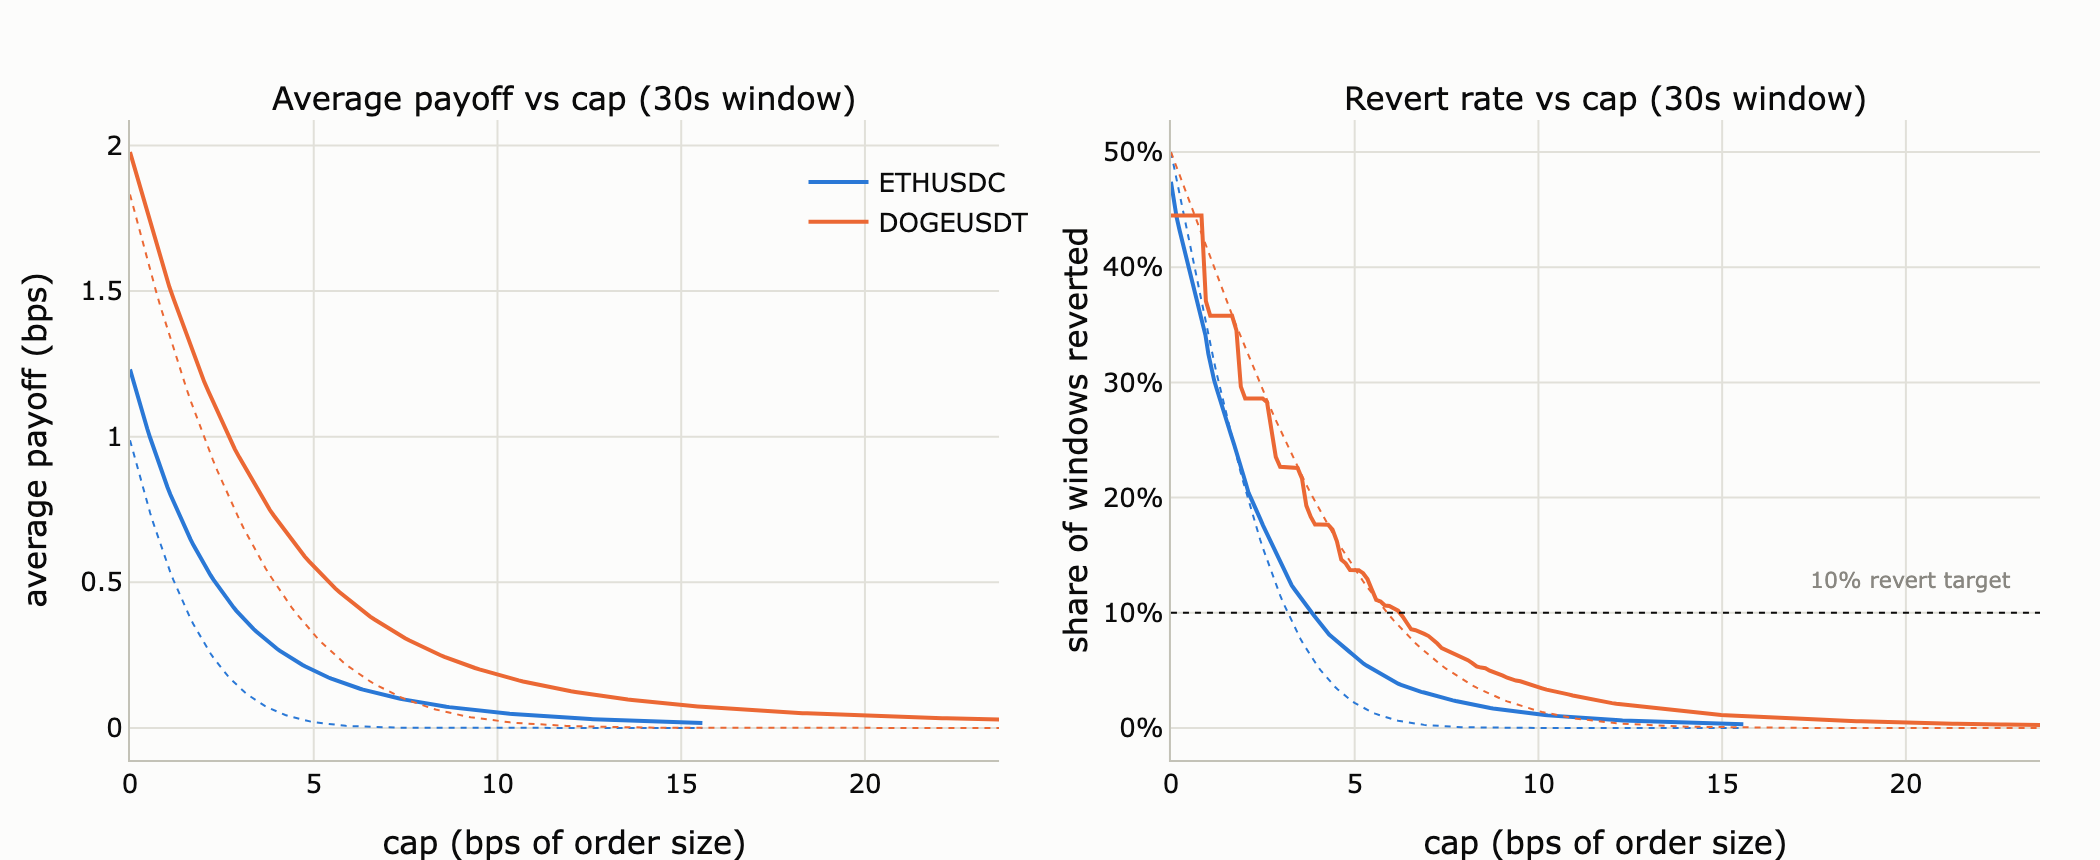

Solid: data. Dotted: normal model at the TSRV vol. Revert curves shown at a truthful bid;
optimal-bid caps are in the table below.


In [12]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=(f"Average payoff vs cap ({T_EXCL}s window)",
                                    f"Revert rate vs cap ({T_EXCL}s window)"))
for pair in PAIRS_EMP:
    _, end = windows_bps(PX[pair], T_EXCL)
    sT_r = sigma_T(pair, T_EXCL)
    caps = np.linspace(0, 4*max(sT_r, end.std()), 200)
    col = C_PAIR[pair]
    fig.add_trace(go.Scatter(x=caps, y=[np.mean(np.maximum(end, -c)) for c in caps], mode="lines",
                             line=dict(color=col, width=2), name=pair), row=1, col=1)
    fig.add_trace(go.Scatter(x=caps, y=[ov_closed(sT_r, 0, c) for c in caps], mode="lines",
                             line=dict(color=col, width=1, dash="dot"), showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=caps, y=[np.mean(end < -c) for c in caps], mode="lines",
                             line=dict(color=col, width=2), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=caps, y=[p_revert(sT_r, 0, c) for c in caps], mode="lines",
                             line=dict(color=col, width=1, dash="dot"), showlegend=False), row=1, col=2)
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1), row=1, col=2)
fig.add_annotation(text="10% revert target", x=0.97, xref="x2 domain", y=0.13, xanchor="right",
                   showarrow=False, font=dict(color=GRAY, size=11), row=1, col=2)
fig.update_xaxes(title_text="cap (bps of order size)", row=1, col=1)
fig.update_xaxes(title_text="cap (bps of order size)", row=1, col=2)
fig.update_yaxes(title_text="average payoff (bps)", row=1, col=1)
fig.update_yaxes(title_text="share of windows reverted", tickformat=".0%", row=1, col=2)
style(fig, h=430)
fig.update_layout(legend=dict(x=0.35, y=0.95))
fig.show()
print("Solid: data. Dotted: normal model at the TSRV vol. Revert curves shown at a truthful bid;")
print("optimal-bid caps are in the table below.")

In [13]:
K_EMP = {}
print(f"empirical cap at the {Q_TARGET:.0%} revert target (bps of order size):")
print(f"{'pair':10s} {'T(s)':>5s} {'TSRV vol_T':>11s} {'cap tr.':>8s} {'k tr.':>6s} "
      f"{'cap opt.':>9s} {'k opt.':>7s} {'k by day':>12s}")
for pair in PAIRS_EMP:
    K_EMP[pair] = {}
    for T in T_GRID:
        _, end = windows_bps(PX[pair], T)
        sT_r = sigma_T(pair, T)
        cap_tr = float(-np.quantile(end, Q_TARGET))
        k_tr = cap_tr/sT_r
        # optimal-bid version: revert iff move < b* - cap; threshold quantile gives
        # a = q10/sigma, cap_opt = sigma * p_call(a)  (closed chain, no root finding)
        a = np.quantile(end, Q_TARGET)/sT_r
        cap_opt = float(sT_r*p_call(a))
        K_EMP[pair][T] = cap_opt/sT_r
        nd = len(end)//len(DAYS_IS)
        kd = [-np.quantile(end[i*nd:(i+1)*nd], Q_TARGET)/sT_r for i in range(len(DAYS_IS))]
        print(f"{pair:10s} {T:5d} {sT_r:11.2f} {cap_tr:8.2f} {k_tr:6.2f} "
              f"{cap_opt:9.2f} {cap_opt/sT_r:7.2f} {min(kd):5.2f}-{max(kd):4.2f}")
print()
print(f"normal-model references: truthful k = {norm.ppf(1-Q_TARGET):.2f}, optimal-bid k = "
      f"{norm.ppf(1-Q_TARGET)*norm.cdf(norm.ppf(1-Q_TARGET)) + norm.pdf(norm.ppf(1-Q_TARGET)):.2f}.")
print("The day-by-day k spread over the 20 estimation days is the sampling error bar; extending")
print("to 3+ months and more pairs is what pins k down.")

empirical cap at the 10% revert target (bps of order size):
pair        T(s)  TSRV vol_T  cap tr.  k tr.  cap opt.  k opt.     k by day
ETHUSDC       10        1.43     2.05   1.43      2.10    1.47  0.64-2.15
ETHUSDC       30        2.48     3.84   1.55      3.90    1.57  0.72-2.23
ETHUSDC       60        3.50     5.49   1.57      5.58    1.59  0.82-2.29
DOGEUSDT      10        2.65     3.56   1.34      3.67    1.38  0.70-1.92
DOGEUSDT      30        4.59     6.22   1.35      6.41    1.40  0.98-1.92
DOGEUSDT      60        6.49     8.83   1.36      9.09    1.40  0.97-1.99

normal-model references: truthful k = 1.28, optimal-bid k = 1.33.
The day-by-day k spread over the 20 estimation days is the sampling error bar; extending
to 3+ months and more pairs is what pins k down.


## 8. Out-of-sample validation (May 21-25)

Everything decision-relevant is estimated on May 1-20 and tested on five days the estimates never saw:
- Coverage: for every unseen window, predict a +-z x sigma_1s x sqrt(T) band, with sigma either the full in-sample TSRV vol (static) or re-estimated from the preceding 5-minute block (rolling, the recurring recalculation a live system would run). The table reports two-sided 95% coverage and the one-sided 10% breach rate the cap cares about.
- The cap itself: apply the in-sample cap (empirical `k` x in-sample vol, revert threshold at the equilibrium bid) to the held-out days and record the realized revert rate against the 10% target.
- The sqrt-of-time scaling check fits the in-sample quantiles across horizons: a slope near 0.5 validates scaling volatility from 5-minute estimates down to short windows.

In [14]:
ZQ = norm.ppf(1 - Q_TARGET)
print("out-of-sample May 21-25 (estimates from May 1-20):")
print(f"{'pair':10s} {'T(s)':>5s} {'n':>7s} {'95% cov static':>15s} {'95% cov rolling':>16s} "
      f"{'10% breach st.':>15s} {'roll.':>6s} {'revert@IS cap':>14s}")
for pair in PAIRS_EMP:
    sig_roll = SIG_BLOCKS_OOS[pair]
    for T in T_GRID:
        _, end = windows_bps(PX_OOS[pair], T)
        sT_is = sigma_T(pair, T)
        # static in-sample vol
        cov_s = np.mean(np.abs(end) <= 1.96*sT_is)
        br_s = np.mean(end < -ZQ*sT_is)
        # rolling prior-block vol within the held-out stream
        idx = (np.arange(len(end))*T)//WINDOW_VOL_S - 1
        ok = (idx >= 0) & (idx < len(sig_roll))
        s_prev = np.where(ok, sig_roll[np.clip(idx, 0, len(sig_roll) - 1)], np.nan)*np.sqrt(T)
        m = ~np.isnan(s_prev)
        cov_r = np.mean(np.abs(end[m]) <= 1.96*s_prev[m])
        br_r = np.mean(end[m] < -ZQ*s_prev[m])
        # forward test of the in-sample cap, revert threshold at the equilibrium bid
        cap_is = K_EMP[pair][T]*sT_is
        c = cap_is/sT_is
        thr = (beta_star(c) - c)*sT_is
        fwd = np.mean(end < thr)
        print(f"{pair:10s} {T:5d} {len(end):7,} {cov_s:15.1%} {cov_r:16.1%} "
              f"{br_s:15.1%} {br_r:6.1%} {fwd:14.1%}")
print("(nominal: 95% coverage, 10% breach, 10% revert)")
fwd_all = []
for pair in PAIRS_EMP:
    for T in T_GRID:
        _, e = windows_bps(PX_OOS[pair], T)
        cp = K_EMP[pair][T]*sigma_T(pair, T); cc = cp/sigma_T(pair, T)
        fwd_all.append(np.mean(e < (beta_star(cc) - cc)*sigma_T(pair, T)))
print(f"in-sample caps held out of sample: realized revert rates {min(fwd_all):.1%}-{max(fwd_all):.1%} vs the 10% target")
print()
print("sqrt-of-time scaling, in-sample: slope of log(move magnitude exceeded 10% of the time) vs log(T)")
for pair in PAIRS_EMP:
    Ts = np.array([5, 10, 30, 60, 120, 300])
    qs = []
    for T in Ts:
        _, end = windows_bps(PX[pair], int(T))
        qs.append(np.quantile(np.abs(end), 0.90))
    H = np.polyfit(np.log(Ts), np.log(qs), 1)[0]
    pred10 = qs[-1]*np.sqrt(10/300)
    print(f"  {pair:10s} fitted slope H = {H:.2f} (sqrt-of-time = 0.50) | "
          f"q10s predicted from 5min: {pred10:.2f} bps vs realized {qs[1]:.2f} bps")

out-of-sample May 21-25 (estimates from May 1-20):
pair        T(s)       n  95% cov static  95% cov rolling  10% breach st.  roll.  revert@IS cap
ETHUSDC       10  43,199           88.9%            89.0%           11.0%  11.0%           9.5%
ETHUSDC       30  14,399           87.9%            87.6%           12.6%  12.9%           9.5%
ETHUSDC       60   7,199           87.7%            87.0%           13.0%  13.5%           9.8%
DOGEUSDT      10  43,199           95.4%            91.9%            6.3%   9.0%           6.3%
DOGEUSDT      30  14,399           95.4%            91.6%            6.5%  10.6%           6.0%
DOGEUSDT      60   7,199           95.0%            90.9%            7.6%  11.6%           6.3%
(nominal: 95% coverage, 10% breach, 10% revert)
in-sample caps held out of sample: realized revert rates 6.0%-9.8% vs the 10% target

sqrt-of-time scaling, in-sample: slope of log(move magnitude exceeded 10% of the time) vs log(T)
  ETHUSDC    fitted slope H = 0.52 (sqrt-of-ti

## 9. The cap formula

Derivation:
1. At the tie, the winner's payoff is `max(Y, -cap, -s_ref)`, with `Y` the surplus move over the window, approximately normal with `sigma_T = sigma_1s x sqrt(T)`.
2. A solver who placed the equilibrium bid reverts when the move falls below `b* - cap`, so the revert probability is `Phi((b* - cap)/sigma_T)`.
3. Fix the revert-rate target `q` and invert. At the optimal bid this has the closed form `cap = sigma_T x [z(1-q) Phi(z(1-q)) + phi(z(1-q))]`; the tick replay replaces the normal quantile with its empirical counterpart `k`.

> **cap(order) = k x sigma_1s(pair) x sqrt(T) x order size**

- `sigma_1s`: the pair's TSRV per-second vol (Section 1), refreshed on a rolling basis. Section 8: on five held-out days the in-sample cap kept realized revert rates at or under the 10% target, and one-sided breach rates land within a few points of nominal; ETHUSDC's two-sided tails are fatter than normal, one more reason k is read from data.
- `T`: the settlement window from chain config (~30s exclusivity today; ~2s fast path scales down by sqrt(15)).
- `k`: 1.33 at the 10% target under optimal bidding (1.28 truthful); empirically higher on this sample, printed in Section 7 (roughly 1.35-1.6). Under the total-revert convention with 5% forced reverts, k rises further (Section 5); that convention choice moves the cap more than any modeling detail and is a policy call.

The table evaluates the formula per pair and window. Against the benchmarks: a flat 2-3 bps cap roughly fits the majors at short windows but underprices a long-tail pair several-fold, and fixed USD caps mis-scale by construction (the same $21 is 21 bps of a $10k order and 0.2 bps of a $1M one). The put value remaining at the chosen cap is a known, deliberate subsidy.

**Caveats.** The cap binds only where `cap < s_ref` (in close auctions the score is the floor). Estimated on 20 days and validated on 5 held-out days; extending to 3+ months remains next. The 2s row is formula-only: at that horizon the empirical quantile measures tick bounce, not volatility (validating it needs bid-ask mid data). Reference score exogenous; vol bands pass through linearly.

**Next steps.** Pin `k` on 1-3 months and more pairs; decide the revert-rate convention (total vs price-driven); correlated-bucket fallback for pairs without CEX data; bid-ask mid data for the fast-path horizon; feed the capped penalty into the counterfactual re-pricing backtest.

In [15]:
K_NORM_OPT = norm.ppf(1 - Q_TARGET)*norm.cdf(norm.ppf(1 - Q_TARGET)) + norm.pdf(norm.ppf(1 - Q_TARGET))
def k_for(pair, T):
    if pair in K_EMP and T in K_EMP[pair]: return K_EMP[pair][T], "empirical"
    if pair == LONG_KEY and T in K_EMP.get("DOGEUSDT", {}): return K_EMP["DOGEUSDT"][T], "DOGE proxy"
    return K_NORM_OPT, "normal"

print(f"cap(order) = k x sigma_1s x sqrt(T) x size | {Q_TARGET:.0%} revert target, optimal bidding, "
      f"price-driven convention (bps of order size)")
print(f"{'pair':30s} {'T(s)':>5s} {'vol_T':>6s} {'k':>5s} {'k source':>11s} {'cap bps':>8s}")
for pair in SIGMA_1S:
    for T in [T_FAST] + T_GRID:
        k, srcname = k_for(pair, T)
        flag = " (formula-only)" if T == T_FAST else ""
        print(f"{pair:30s} {T:5d} {sigma_T(pair, T):6.2f} {k:5.2f} {srcname:>11s} "
              f"{k*sigma_T(pair, T):8.2f}{flag}")
print()
print(f"total-revert convention (p_f = {P_FORCED:.0%}): multiply the k column by "
      f"{K_CONV['total']/K_CONV['price']:.2f}")
print()
print("benchmarks: flat cap idea 2-3 bps | protocol fee ~2 bps | current fixed USD caps:")
for usd, name in [(21.15, "ethereum"), (24.72, "bnb"), (2.62, "polygon")]:
    print(f"  {name:9s} ${usd:5.2f}: $10k order = {usd/10_000*1e4:5.1f} bps | "
          f"$100k = {usd/100_000*1e4:5.2f} bps | $1M = {usd/1_000_000*1e4:5.3f} bps")

cap(order) = k x sigma_1s x sqrt(T) x size | 10% revert target, optimal bidding, price-driven convention (bps of order size)
pair                            T(s)  vol_T     k    k source  cap bps
ETHUSDC                            2   0.64  1.33      normal     0.85 (formula-only)
ETHUSDC                           10   1.43  1.47   empirical     2.10
ETHUSDC                           30   2.48  1.57   empirical     3.90
ETHUSDC                           60   3.50  1.59   empirical     5.58
DOGEUSDT                           2   1.19  1.33      normal     1.58 (formula-only)
DOGEUSDT                          10   2.65  1.38   empirical     3.67
DOGEUSDT                          30   4.59  1.40   empirical     6.41
DOGEUSDT                          60   6.49  1.40   empirical     9.09
LONGTAIL (synthetic, 5x DOGE)      2   5.93  1.33      normal     7.88 (formula-only)
LONGTAIL (synthetic, 5x DOGE)     10  13.25  1.38  DOGE proxy    18.34
LONGTAIL (synthetic, 5x DOGE)     30  22.96  1.40